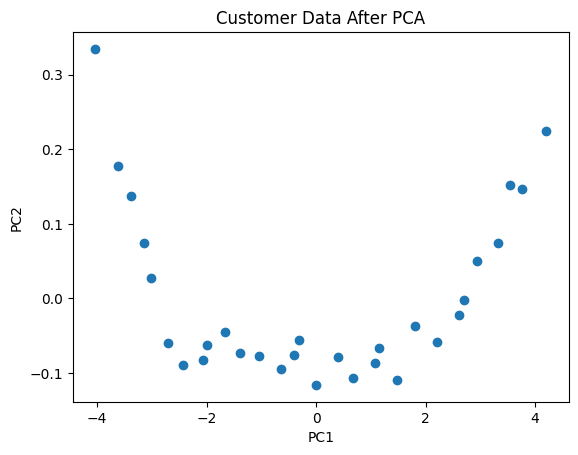

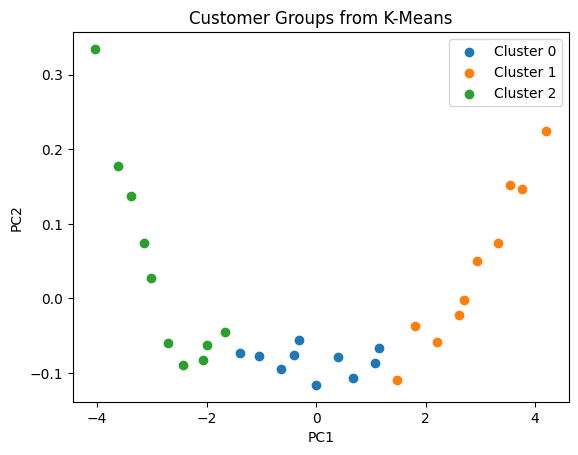

In [13]:
import pandas as pd
import pandas as pd

data = {
    "Customer_ID": range(1, 31),

    "Age": [
        19, 21, 22, 24, 25, 27, 29, 31, 33, 35,
        36, 38, 40, 42, 44, 46, 48, 50, 52, 54,
        56, 58, 60, 62, 23, 28, 37, 45, 53, 59
    ],

    "Annual_Income": [
        22, 25, 27, 30, 32, 35, 38, 42, 45, 48,
        52, 55, 58, 62, 65, 68, 72, 76, 80, 84,
        88, 92, 98, 105, 29, 40, 57, 70, 86, 96
    ],

    "Monthly_Spending": [
        18, 20, 23, 25, 28, 30, 34, 38, 40, 43,
        48, 50, 54, 58, 60, 64, 68, 72, 75, 80,
        84, 88, 92, 96, 24, 36, 52, 66, 82, 90
    ],

    "Purchases_Per_Month": [
        2, 3, 3, 4, 5, 5, 6, 7, 7, 8,
        9, 9, 10, 11, 11, 12, 13, 13, 14, 15,
        15, 16, 17, 18, 4, 6, 9, 12, 15, 16
    ],

    "Website_Visits_Per_Month": [
        8, 10, 12, 14, 15, 17, 19, 22, 24, 26,
        28, 30, 32, 35, 37, 40, 42, 45, 48, 50,
        53, 55, 58, 60, 13, 20, 31, 41, 51, 57
    ],

    "Discount_Usage_Percent": [
        70, 65, 62, 58, 55, 52, 50, 48, 45, 43,
        40, 38, 35, 33, 30, 28, 25, 23, 20, 18,
        16, 14, 12, 10, 60, 49, 37, 27, 17, 13
    ]
}

df = pd.DataFrame(data)

df.head()
df.shape
df.columns
X = df[
    [
        "Age",
        "Annual_Income",
        "Monthly_Spending",
        "Purchases_Per_Month",
        "Website_Visits_Per_Month",
        "Discount_Usage_Percent"
    ]
]

X.head()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca
pca.explained_variance_ratio_.sum()
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()
pca_df["Customer_ID"] = df["Customer_ID"]
pca_df

import matplotlib.pyplot as plt

plt.scatter(pca_df["PC1"], pca_df["PC2"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Data After PCA")

plt.show()

from sklearn.cluster import KMeans

# Create K-Means model
model = KMeans(n_clusters=3, random_state=42)

# Train model on PCA data
model.fit(X_pca)

# Add cluster labels
pca_df["Cluster"] = model.labels_

# Show results
pca_df.head()

import matplotlib.pyplot as plt

for cluster in sorted(pca_df["Cluster"].unique()):
    group = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(group["PC1"], group["PC2"], label=f"Cluster {cluster}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Groups from K-Means")
plt.legend()
plt.show()